In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cosmic.evolve import Evolve
from cosmic.sample.initialbinarytable import InitialBinaryTable
import matplotlib.pyplot as plt

from eventlab.events import build_mask, get_events
from eventlab.dtd import get_dtd

import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'figure.figsize': (7, 5),
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

### Let's work through a basic example. We will create the DTD of RSGs in a 'population' which is just one star for now. First let's evolve it and save the full bcm.

In [2]:
def single_system(m1=15, m2=0, porb=-1, ecc=-1, tphysf=13700.0, kstar1=1, kstar2=15, metallicity=0.014, engine='metisse', track_to_paths='../../METISSE/NewWindsAndNewCBM'):
    star = InitialBinaryTable.InitialBinaries(m1=m1, m2=m2, porb=porb, ecc=ecc, tphysf=tphysf, kstar1=kstar1, kstar2=kstar2, metallicity=metallicity)
    SSEDict = {'stellar_engine': engine, 'z_accuracy_limit': 0.01,
               'path_to_tracks': f'{track_to_paths}/hydrogen',
               'path_to_he_tracks': f'{track_to_paths}/helium'}
    
    BSEDict = {
        "pts1": 0.001, "pts2": 0.01, "pts3": 0.02, "zsun": 0.014, "windflag": 3,
        "eddlimflag": 0, "neta": 0.5, "bwind": 0.0, "hewind": 0.5, "beta": 0.125,
        "xi": 0.5, "acc2": 1.5, "LBV_flag": 1, "alpha1": [1.0, 1.0],
        "lambdaf": 0.0, "ceflag": 1, "cekickflag": 2, "cemergeflag": 1,
        "cehestarflag": 0, "qcflag": 5,
        "qcrit_array": [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
        "kickflag": 5, "sigma": 265.0, "bhflag": 1, "bhsigmafrac": 1.0,
        "sigmadiv": -20.0, "ecsn": 2.25, "ecsn_mlow": 1.6, "aic": 1, "ussn": 1,
        "polar_kick_angle": 90.0,
        "natal_kick_array": [[-100.0, -100.0, -100.0, -100.0, 0.0], [-100.0, -100.0, -100.0, -100.0, 0.0]],
        "mm_mu_ns": 400.0, "mm_mu_bh": 200.0, "remnantflag": 4,
        "fryer_mass_limit": 0, "mxns": 3.0, "fryer_fmix": 1.0,
        "fryer_mcrit_nsbh": 5.75, "rembar_massloss": 0.5, "wd_mass_lim": 1,
        "maltsev_mode": 0, "maltsev_fallback": 0.5, "maltsev_pf_prob": 0.1,
        "pisn": -2, "ppi_co_shift": 0.0, "ppi_extra_ml": 0.0, "bhspinflag": 0,
        "bhspinmag": 0.0, "grflag": 1, "eddfac": 10, "gamma": -2, "don_lim": -1,
        "acc_lim": [-1, -1], "smt_periastron_check": 0, "tflag": 1, "ST_tide": 1,
        "fprimc_array": [2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0],
        "ifflag": 1, "wdflag": 1, "epsnov": 0.001, "bdecayfac": 1,
        "bconst": 3000, "ck": 1000, "rejuv_fac": 1.0, "rejuvflag": 0,
        "bhms_coll_flag": 0, "htpmb": 1, "ST_cr": 1, "rtmsflag": 0
    }

    timesteps = [[f'kstar_1 <= 10', 'dtp=0.0'], [f'kstar_2 <= 10', 'dtp=0.0']]
    bpp, bcm, initC, kick_info = Evolve.evolve(initialbinarytable=star, BSEDict=BSEDict, SSEDict=SSEDict, timestep_conditions=timesteps)

    return bpp, bcm[bcm.tphys < 13700.0]

In [3]:
# adjust the track to paths to point to the METISSE tracks on your system
bpp_single, bcm_single = single_system(m1=6, metallicity=0.014, engine='metisse', track_to_paths='../../METISSE/NewWindsAndNewCBM')

### Here we will just define a RSG as falling within our temperature and luminosity range simultaneously

In [4]:
teff_range = (2900, 4500)
lum_range = (3000, 6e5)

primary_mask = build_mask(bcm_single,
                          [('teff_1', 'greater_equal', teff_range[0]),
                           ('teff_1', 'less_equal',    teff_range[1]),
                           ('lum_1',  'greater_equal', lum_range[0]),
                           ('lum_1',  'less_equal',    lum_range[1])],
                          mask_logic='and')

secondary_mask = build_mask(bcm_single,
                            [('teff_2', 'greater_equal', teff_range[0]),
                             ('teff_2', 'less_equal',    teff_range[1]),
                             ('lum_2',  'greater_equal', lum_range[0]),
                             ('lum_2',  'less_equal',    lum_range[1])],
                            mask_logic='and')

mask = primary_mask | secondary_mask

### Using our masks, create an event dataframe

In [5]:
event_df = get_events(
    bcm_single,
    mask,
    stats_dict={'teff_1': ['max', 'min', 'median', 'mean'], 'lum_1': ['max', 'min', 'median', 'mean'], 'mass_1': ['first', 'last']},
)

event_df

,bin_num,tphys_start,tphys_end,duration,lum_1_max,lum_1_mean,lum_1_median,lum_1_min,mass_1_first,mass_1_last,teff_1_max,teff_1_mean,teff_1_median,teff_1_min
0,0,66.357669,69.616637,3.258968,6246.648759,4692.247113,4695.529691,3019.637075,5.995309,5.983218,4455.360319,4022.159257,3980.989453,3873.340418
1,0,72.107656,73.193693,1.086036,20723.598446,8729.466417,8056.789382,3427.205198,5.978064,3.729152,4458.827513,3793.468033,3788.109485,3270.497561


We have two distinct RSG intervals, where the bcm rows between the intervals do not satisy the condition! Visually we can confirm there are two 'RSG' phases:

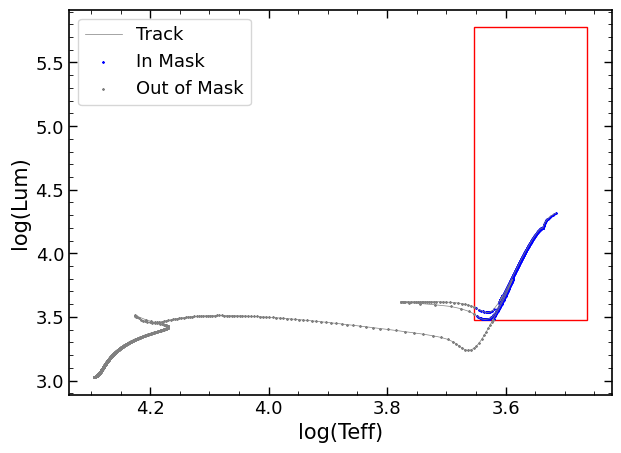

In [6]:
fig, ax = plt.subplots()

# plot the rectangle which visually represents the event mask
rect = plt.Rectangle((np.log10(teff_range[1]), np.log10(lum_range[0])),
                     np.log10(teff_range[0]) - np.log10(teff_range[1]),
                     np.log10(lum_range[1]) - np.log10(lum_range[0]),
                     linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)

# plot the points of the hr diagram -- point in the mask are blue, outside grey
ax.plot(np.log10(bcm_single['teff_1']), np.log10(bcm_single['lum_1']), color='grey', linewidth=0.5, label='Track')
ax.scatter(np.log10(bcm_single[primary_mask]['teff_1']), np.log10(bcm_single[primary_mask]['lum_1']), color='blue', s=1, marker='*', label='In Mask')
ax.scatter(np.log10(bcm_single[~primary_mask]['teff_1']), np.log10(bcm_single[~primary_mask]['lum_1']), color='grey', s=1, marker='*', label='Out of Mask')

ax.legend()
ax.set_xlabel('log(Teff)')
ax.invert_xaxis()
ax.set_ylabel('log(Lum)')
plt.show()

Now we build a DTD and plot it. Each interval independently contributes DTD power. Intervals which overlap bins contribute power to each as the ratio of their duration in that bin / bin length

In [7]:
sample_mass = 1 # DTDs are normalized by sample mass. We use a dummy quantity 1 here so you can see how the DTD is computed.
bins = [64, 66, 68, 70, 72, 74, 76]
dtd_df = get_dtd(event_df, bins=bins, sample_mass=sample_mass)
dtd_df

,bin_start,bin_end,power
0,64.0,66.0,0.000000
1,66.0,68.0,0.821166
2,68.0,70.0,0.808319
3,70.0,72.0,0.000000
4,72.0,74.0,0.543018
5,74.0,76.0,0.000000


The dtd dataframe gives you the power in each bin!

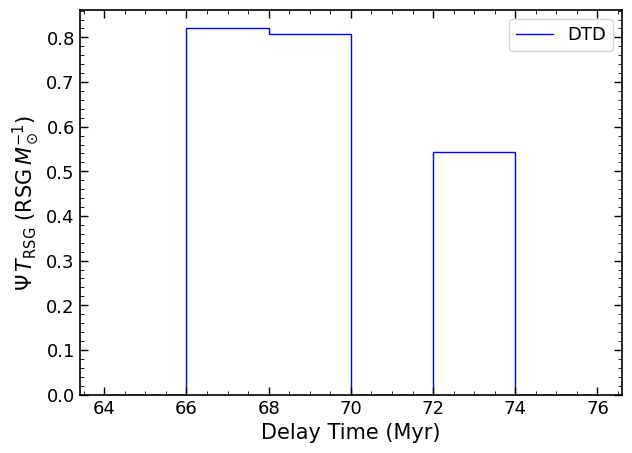

In [8]:
# now plot the DTD with ax.stairs
fig, ax = plt.subplots()
ax.stairs(dtd_df['power'], bins, label='DTD', color='blue')
ax.set_xlabel(r"Delay Time (Myr)")
ax.set_ylabel(r"$\Psi \, T_{\rm RSG}$ (${\rm RSG} \, M_\odot^{-1}$)")
ax.legend()
plt.show()

### Let's evolve a binary and include interaction history

In [9]:
bpp_binary, bcm_binary = single_system(m1=15, m2=6, kstar1=1, kstar2=1, porb=2e3, ecc=0, metallicity=0.014, engine='metisse', track_to_paths='../../METISSE/NewWindsAndNewCBM')

In [10]:
primary_mask_binary = build_mask(bcm_binary,
                          [('teff_1', 'greater_equal', teff_range[0]),
                           ('teff_1', 'less_equal',    teff_range[1]),
                           ('lum_1',  'greater_equal', lum_range[0]),
                           ('lum_1',  'less_equal',    lum_range[1])],
                          mask_logic='and')

secondary_mask_binary = build_mask(bcm_binary,
                            [('teff_2', 'greater_equal', teff_range[0]),
                             ('teff_2', 'less_equal',    teff_range[1]),
                             ('lum_2',  'greater_equal', lum_range[0]),
                             ('lum_2',  'less_equal',    lum_range[1])],
                            mask_logic='and')

Now in order to hold onto the data of whic events come from secondaries and which are from primaries, we will call `get_events` twice with each mask, and add a `star` column as a tag!

In [11]:
event_df_1 = get_events(
    bcm_binary,
    primary_mask_binary,
    stats_dict={'teff_1': ['max', 'min', 'median', 'mean'], 'lum_1': ['max', 'min', 'median', 'mean'], 'mass_1': ['max', 'min'], 'kstar_1': ['first', 'last']},
    include_interaction_info=True,
    bpp=bpp_binary #need to include the bpp now that we are including interaction info
)
event_df_1['star'] = 1

event_df_2 = get_events(
    bcm_binary,
    secondary_mask_binary,
    stats_dict={'teff_2': ['max', 'min', 'median', 'mean'], 'lum_2': ['max', 'min', 'median', 'mean'], 'mass_2': ['max', 'min'], 'kstar_2': ['first', 'last']},
    include_interaction_info=True,
    bpp=bpp_binary #need to include the bpp now that we are including interaction info
)
event_df_2['star'] = 2

event_df_binary = pd.concat([event_df_1, event_df_2], ignore_index=True).sort_values(['bin_num', 'tphys_start']).reset_index(drop=True)
event_df_binary

,bin_num,tphys_start,tphys_end,duration,kstar_1_first,kstar_1_last,lum_1_max,lum_1_mean,lum_1_median,lum_1_min,mass_1_max,mass_1_min,teff_1_max,teff_1_mean,teff_1_median,teff_1_min,pre_event_interactions,during_event_interactions,pre_event_merger,during_event_merger,pre_event_merger_type,during_event_merger_type,pre_event_donor_kstars_1,pre_event_donor_kstars_2,pre_event_accretor_kstars_1,pre_event_accretor_kstars_2,during_event_donor_kstars_1,during_event_donor_kstars_2,during_event_accretor_kstars_1,during_event_accretor_kstars_2,star,kstar_2_first,kstar_2_last,lum_2_max,lum_2_mean,lum_2_median,lum_2_min,mass_2_max,mass_2_min,teff_2_max,teff_2_mean,teff_2_median,teff_2_min
0,0,12.942623,13.989838,1.047215,2.0,4.0,100305.842327,78666.804813,79969.297112,41411.167495,14.927507,12.109865,4360.460423,3591.420703,3573.431938,3439.288549,None,RLOF,False,False,None,None,None,None,None,None,4,None,None,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,13.992935,13.992935,0.000000,5.0,5.0,102693.990124,102693.990124,102693.990124,102693.990124,12.089838,12.089838,3430.432019,3430.432019,3430.432019,3430.432019,RLOF,CEE,False,False,None,None,4,None,None,1,5,None,None,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,61.809840,64.832915,3.023075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CEE,None,False,False,None,None,4-5,None,None,1,None,None,None,None,2,3.0,4.0,7234.049075,5426.286966,5435.082313,3123.249798,6.245764,6.232270,4495.685276,3995.482982,3953.534084,3845.998441
3,0,66.940254,67.891073,0.950819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CEE,None,False,False,None,None,4-5,None,None,1,None,None,None,None,2,4.0,5.0,22269.924580,9849.873843,9266.527112,4016.837844,6.227141,3.571415,4449.446567,3768.690330,3762.362363,3239.063812
